In [17]:
import control as c
import sympy as sy
import numpy as np
from scipy.integrate import solve_bvp
from matplotlib import pyplot as plt

In [2]:
# variables from control.py
x, u, lam = c.define_variables()
L_def = c.L(x, u)
H_def = c.H(c.sy_f_full(seasonal=False), L_def, lam)            # no_dead=True is default

In [3]:
x_dot, lam_dot, stationary = c.hamiltionian_partials(H_def, x, lam, sy.Matrix([u[1]]))
print(x_dot)
print(lam_dot)
print(stationary)
stationary

Matrix([[-I*S*α + I*u2*η/(100*I + 5000) - S*ζ*(-2*T1/(365*u1) + 1) + T1*γ], [I*S*α - I*u2*η/(100*I + 5000) - I*β - I*ζ*(-2*T1/(365*u1) + 1)], [-T1*γ + ζ*(I + S)*(-2*T1/(365*u1) + 1)]])
Matrix([[-I*l2*α - l1*(-I*α - ζ*(-2*T1/(365*u1) + 1)) - l3*ζ*(-2*T1/(365*u1) + 1)], [6*I - l1*(-100*I*u2*η/(100*I + 5000)**2 - S*α + u2*η/(100*I + 5000)) - l2*(100*I*u2*η/(100*I + 5000)**2 + S*α - u2*η/(100*I + 5000) - β - ζ*(-2*T1/(365*u1) + 1)) - l3*ζ*(-2*T1/(365*u1) + 1)], [-2*I*l2*ζ/(365*u1) - l1*(2*S*ζ/(365*u1) + γ) - l3*(-γ - 2*ζ*(I + S)/(365*u1))]])
Matrix([[I*l1*η/(100*I + 5000) - I*l2*η/(100*I + 5000) - 2*u2]])


Matrix([[I*l1*η/(100*I + 5000) - I*l2*η/(100*I + 5000) - 2*u2]])

In [6]:
u_sol = sy.solve(stationary, u[1])
for s in u_sol:
    print(sy.simplify(s))

u_real = sy.simplify(u_sol)
u_real

u2


{u2: (I*l1*η - I*l2*η)/(200*I + 10000)}

In [9]:
# sub_dict = {
#     'u1': u_real[0],
#     'u2': u_real[1] 
# }
sub_dict = u_real

lam_new = lam_dot.subs(sub_dict)
x_new = x_dot.subs(sub_dict)
print(lam_new)
print(x_new)

Matrix([[-I*l2*α - l1*(-I*α - ζ*(-2*T1/(365*u1) + 1)) - l3*ζ*(-2*T1/(365*u1) + 1)], [6*I - l1*(-100*I*η*(I*l1*η - I*l2*η)/((100*I + 5000)**2*(200*I + 10000)) - S*α + η*(I*l1*η - I*l2*η)/((100*I + 5000)*(200*I + 10000))) - l2*(100*I*η*(I*l1*η - I*l2*η)/((100*I + 5000)**2*(200*I + 10000)) + S*α - β - ζ*(-2*T1/(365*u1) + 1) - η*(I*l1*η - I*l2*η)/((100*I + 5000)*(200*I + 10000))) - l3*ζ*(-2*T1/(365*u1) + 1)], [-2*I*l2*ζ/(365*u1) - l1*(2*S*ζ/(365*u1) + γ) - l3*(-γ - 2*ζ*(I + S)/(365*u1))]])
Matrix([[-I*S*α + I*η*(I*l1*η - I*l2*η)/((100*I + 5000)*(200*I + 10000)) - S*ζ*(-2*T1/(365*u1) + 1) + T1*γ], [I*S*α - I*β - I*ζ*(-2*T1/(365*u1) + 1) - I*η*(I*l1*η - I*l2*η)/((100*I + 5000)*(200*I + 10000))], [-T1*γ + ζ*(I + S)*(-2*T1/(365*u1) + 1)]])


In [10]:
sy.simplify(lam_new)

Matrix([
[                                                                                                                 I*l1*α - I*l2*α - 2*T1*l1*ζ/(365*u1) + 2*T1*l3*ζ/(365*u1) + l1*ζ - l3*ζ],
[-I*l1**2*η**2/(400*(I + 50)**3) + I*l1*l2*η**2/(200*(I + 50)**3) - I*l2**2*η**2/(400*(I + 50)**3) + 6*I + S*l1*α - S*l2*α - 2*T1*l2*ζ/(365*u1) + 2*T1*l3*ζ/(365*u1) + l2*β + l2*ζ - l3*ζ],
[                                                                                                              (-2*I*l2*ζ - l1*(2*S*ζ + 365*u1*γ) + l3*(365*u1*γ + 2*ζ*(I + S)))/(365*u1)]])

In [11]:
sy.simplify(x_new)

Matrix([
[      (I**2*u1*η**2*(l1 - l2)/20000 + S*ζ*(I + 50)**2*(2*T1 - 365*u1)/365 + u1*(I + 50)**2*(-I*S*α + T1*γ))/(u1*(I + 50)**2)],
[I*(-73*I*u1*η**2*(l1 - l2) + 1460000*u1*(I + 50)**2*(S*α - β) + 4000*ζ*(I + 50)**2*(2*T1 - 365*u1))/(1460000*u1*(I + 50)**2)],
[                                                                               (-T1*u1*γ - ζ*(I + S)*(2*T1 - 365*u1)/365)/u1]])

In [36]:
parameters = {
    "γ": 0.1,
    "ζ": 0.15,
    "η": 1,
    "α": 1e-5,    # guess without seasonal component
    "β": 0.0135,   # guess without seasonal component
    "u1": 150     # 150$ / timestep allows for new builds and maintenance
}   # TODO get parameters to substitute

In [37]:
# get stuff ready to solve

# substitute constant parameters
new_x_dot = x_new.subs(parameters)  
new_lam_dot = lam_new.subs(parameters)

# lambdify
x_dot_func = sy.lambdify((x, lam), new_x_dot, modules="numpy")
lam_dot_func = sy.lambdify((x, lam), new_lam_dot, modules="numpy")

# combine
def ode(t, y):
    """Define an ode where the first n elements are the derivative the compartments
    and the last n elements are the derivative of the lambdas"""
    n = int(len(y)/2)                       # should work with or without the dead term
    dx = x_dot_func(y[:n], y[n:])
    dlam = lam_dot_func(y[:n], y[n:])

    return np.squeeze(np.concatenate((dx, dlam)))

init_x = np.array([250, 245, 5])             # without dead
init_lam = np.array([1, 2, 3])              # without dead

print(lam_dot_func(init_x, init_lam))

# define boundary conditions
def bc(ya, yb):
    return np.squeeze(np.concatenate((ya[:len(init_x)] - init_x, yb[len(init_x):])))

# get other necessary things
tf = 400
t_vals = np.linspace(0, tf, 100)
final_x_guess = np.array([150, 10, 150, 190])
state_init = np.array([np.linspace(init_x[i], final_x_guess[i], len(t_vals)) for i in range(len(init_x))])
costate_init = np.array([np.linspace(.1, .0001, len(init_x)) for _ in range(len(t_vals))]).T   # from Claude, suggested linear decay for costate initial conditions
y_init = np.vstack((state_init, costate_init))


sol = solve_bvp(ode, bc, t_vals, y_init)
print(sol.message)


[[-3.02395205e-01]
 [ 1.46987453e+03]
 [ 2.04082192e-01]]
The algorithm converged to the desired accuracy.


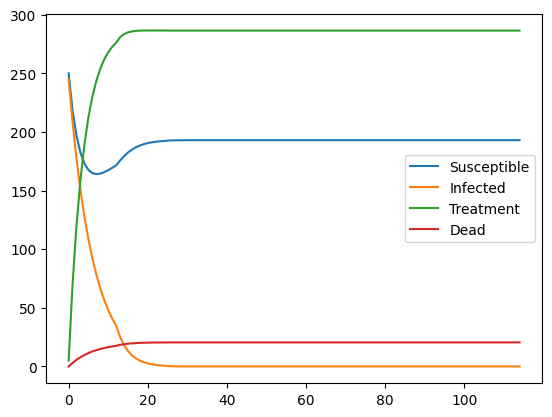

In [38]:
# PLOTS
sol.y.shape
plt.plot(sol.y[0], label="Susceptible")
plt.plot(sol.y[1], label="Infected")
plt.plot(sol.y[2], label="Treatment")
plt.plot(500 - sol.y[0] - sol.y[1] - sol.y[2], label="Dead")
plt.legend()
plt.show()

### Possible Next Steps

- iteratively solve $x$ forward and $\lambda$ backward
- grid search over initial values
